In [1]:
import numpy as np
import re
import pandas as pd
import polars as pl
import scienceplots
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator, RegularGridInterpolator
from scipy.optimize import differential_evolution
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import h5py
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq, fftshift, ifft, ifftshift
import math
from scipy import integrate
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from whittaker_eilers import WhittakerSmoother
from scipy.optimize import curve_fit
from pathlib import Path
from scipy.interpolate import LinearNDInterpolator
from mpl_toolkits.mplot3d import Axes3D
import os
from PIL import Image
from scipy.spatial import cKDTree
from itertools import product

plt.style.use(["science", "no-latex", "grid"])
plt.rcParams.update({'font.size': 12})
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{siunitx}"
plt.rcParams["figure.figsize"] = (14, 7) 

In [2]:
def get_data(filename, csv=True, start_band=0, stop_band=1.8e10):
    if (csv == False): 
        file = h5py.File(filename, 'r')
        freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs = np.linspace(freq_start, freq_stop, probe_pts)
        vals = np.asarray(file['sweep_dataframe']).flatten() 
        
        mask = (freqs >= start_band) & (freqs <= stop_band)
        freqs_window = freqs[mask]
        vals_window = vals[mask]   
        return [freqs_window, vals_window]
    else: 
        df = pl.read_csv(filename)    
        mask = (df[df.columns[0]].to_numpy() >= start_band) & (df[df.columns[0]].to_numpy() <= stop_band)
        return [((df[df.columns[0]]).to_numpy())[mask], ((df[df.columns[1]]).to_numpy())[mask]]

open_freq, open_mag = get_data("time_domain_data/Open_MLOG_08102025.csv")
open_phase = get_data("time_domain_data/Open_PHAS_08102025.csv")[1]

conn_freq, conn_mag = get_data("time_domain_data/Connectors_MLOG_08102025.csv")
conn_phase = get_data("time_domain_data/Connectors_PHAS_08102025.csv")[1]

term50_freq, term50_mag = get_data("time_domain_data/Terminator_50Ohm_MLOG_08102025.csv")
term50_phase = get_data("time_domain_data/Terminator_50Ohm_PHAS_08102025.csv")[1]

term75_freq, term75_mag = get_data("time_domain_data/Terminator_75Ohm_MLOG_08102025.csv")
term75_phase = get_data("time_domain_data/Terminator_75Ohm_PHAS_08102025.csv")[1]

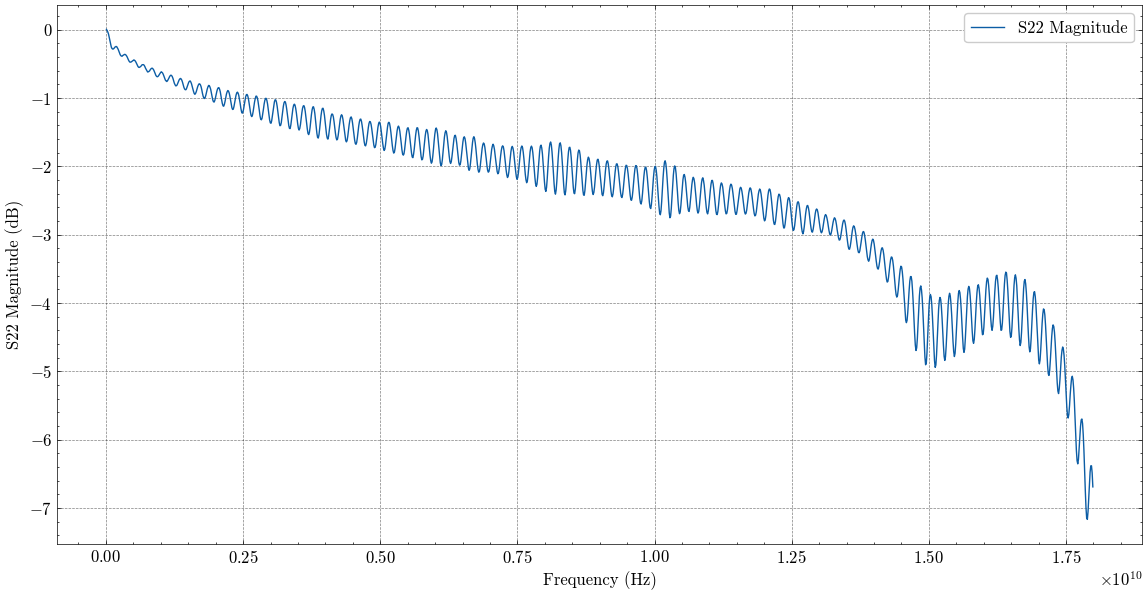

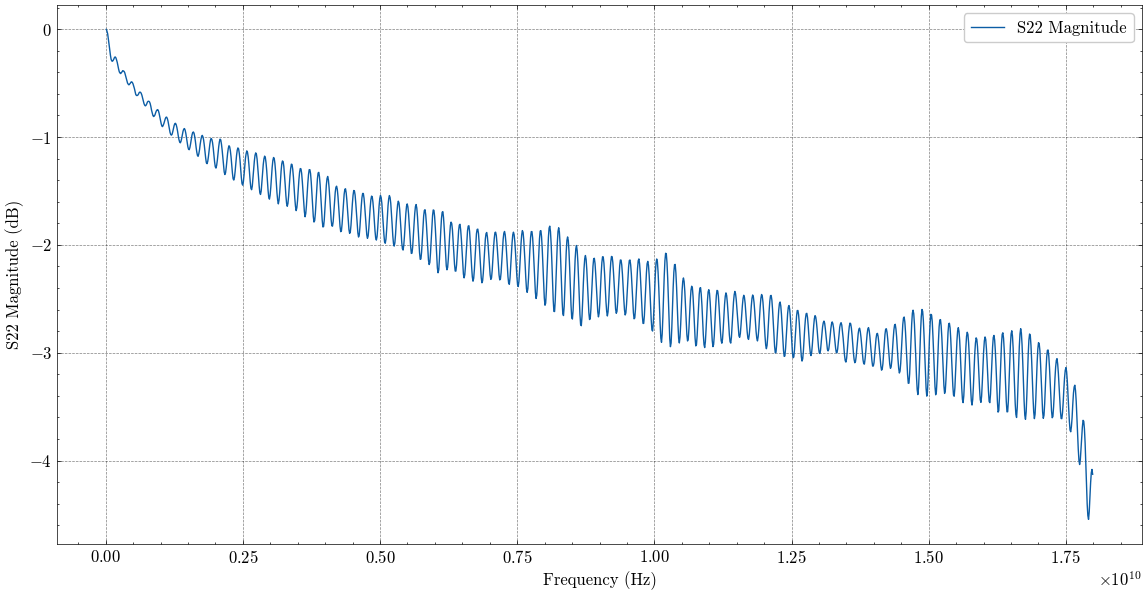

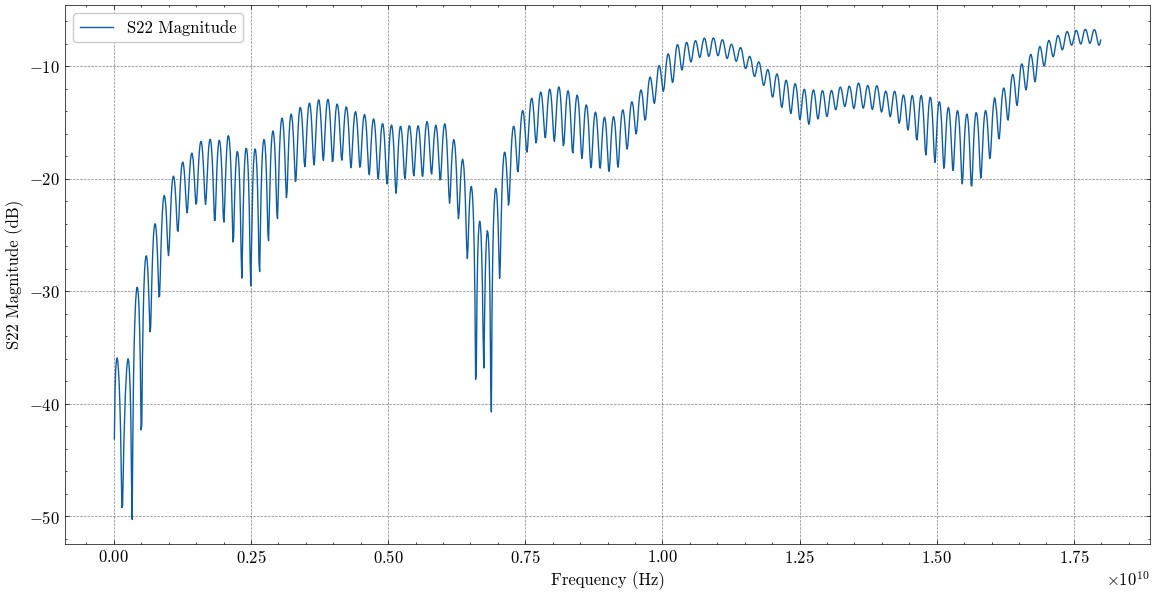

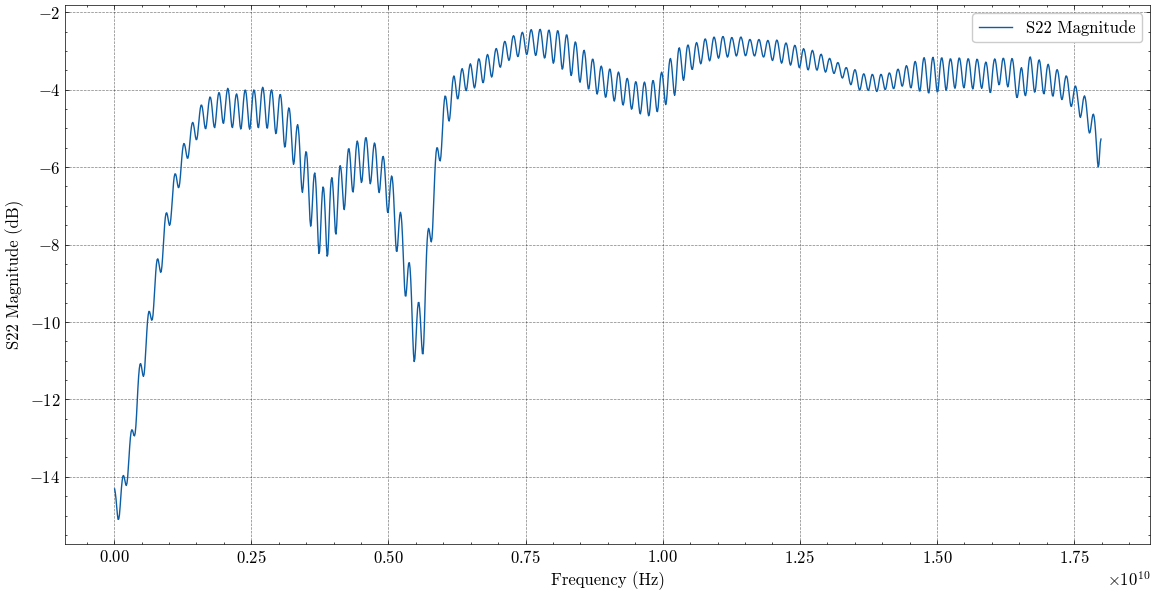

In [3]:
def original_data_plotter(freq, mag, phase, subplot=False):
    if subplot==True:
        fig, axes = plt.subplots(1, 2, figsize=(24, 8))
        
        axes[0].plot(freq, mag, label='S22 Magnitude')
        axes[0].set_xlabel('Frequency (Hz)')
        axes[0].set_ylabel('S22 Magnitude (dB)')
        axes[0].legend()
        
        axes[1].plot(freq, phase, label='S22 Phase Wrapped?}', color='orange')
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('S22 Phase ' + r'$(^{\circ})$')
        axes[1].legend()
        
        fig.suptitle("Measurement Magnitude and Phase Data")
        plt.show()
    else:
        plt.plot(freq, mag, label='S22 Magnitude')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('S22 Magnitude (dB)')
        plt.legend()
        plt.show()
        
original_data_plotter(open_freq, open_mag, open_phase)
original_data_plotter(conn_freq, conn_mag, conn_phase)
original_data_plotter(term50_freq, term50_mag, term50_phase)
original_data_plotter(term75_freq, term75_mag, term75_phase)

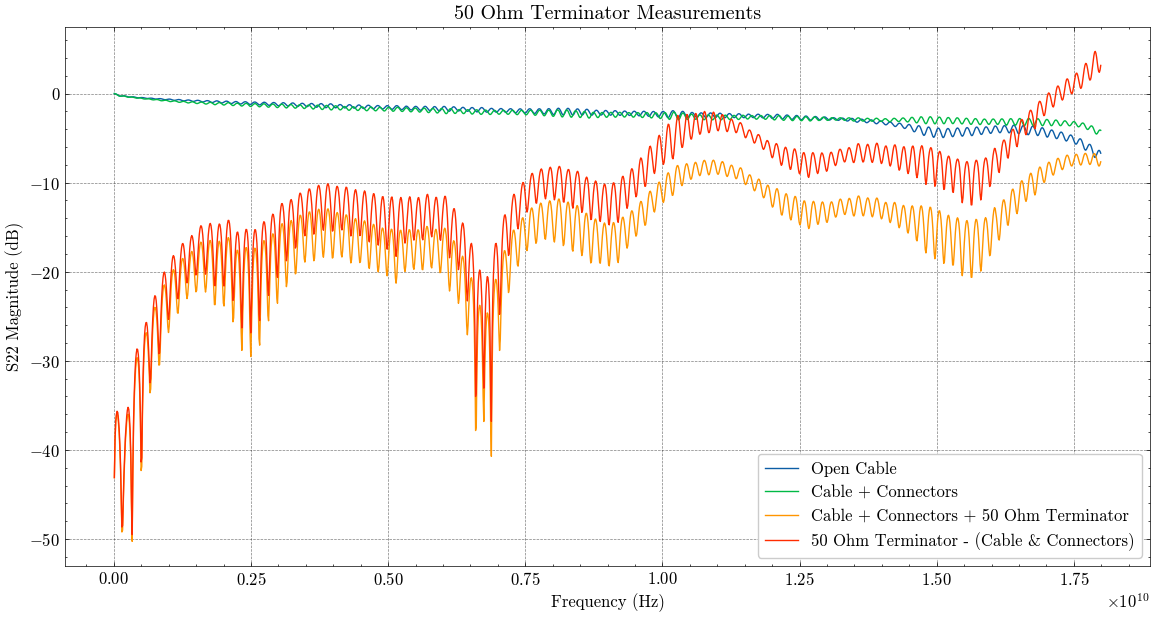

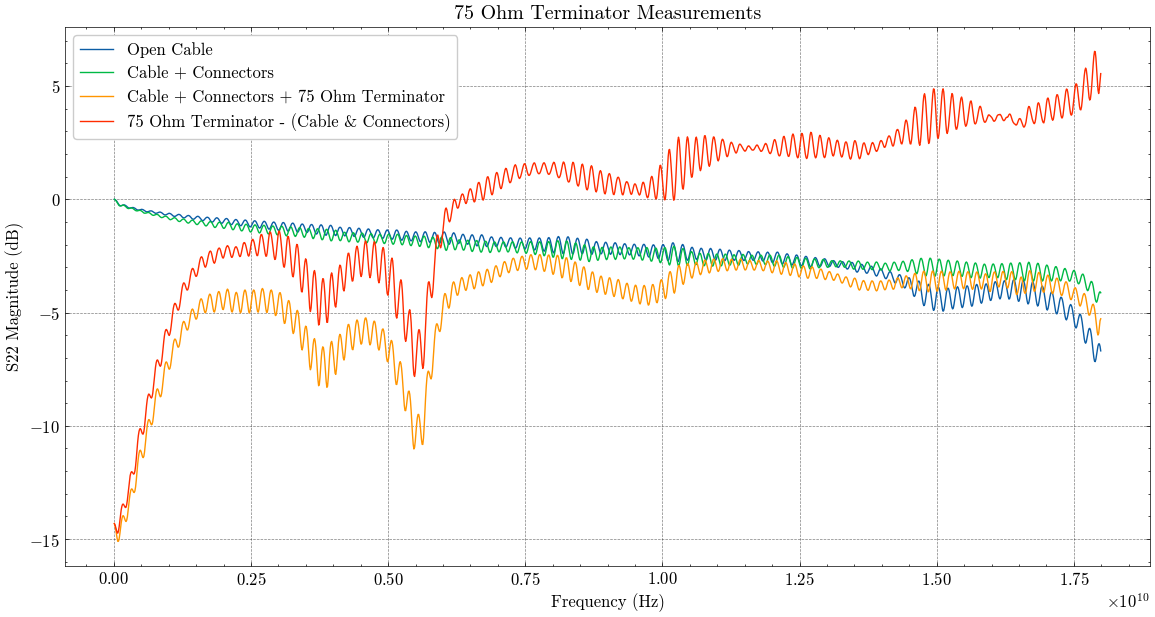

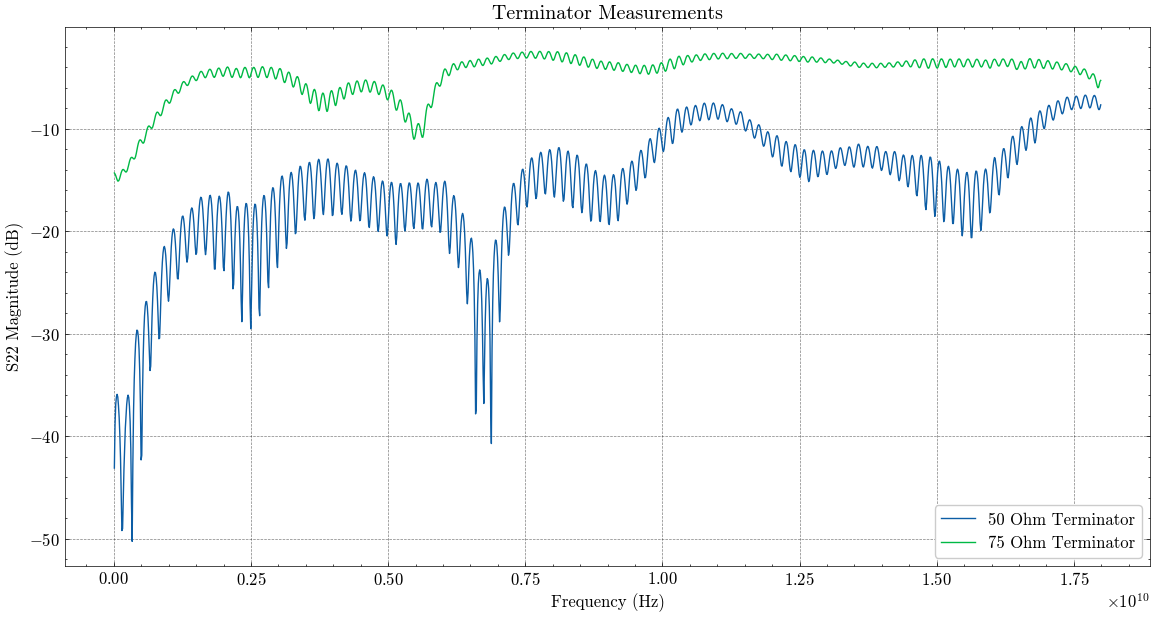

In [4]:
plt.plot(open_freq, open_mag, label='Open Cable')
plt.plot(conn_freq, conn_mag, label='Cable + Connectors')
plt.plot(term50_freq, term50_mag, label='Cable + Connectors + 50 Ohm Terminator')
plt.plot(term50_freq, (term50_mag - conn_mag - open_mag), label='50 Ohm Terminator - (Cable & Connectors)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('S22 Magnitude (dB)')
plt.title('50 Ohm Terminator Measurements')
plt.legend()
plt.show()

plt.plot(open_freq, open_mag, label='Open Cable')
plt.plot(conn_freq, conn_mag, label='Cable + Connectors')
plt.plot(term75_freq, term75_mag, label='Cable + Connectors + 75 Ohm Terminator')
plt.plot(term75_freq, (term75_mag - conn_mag - open_mag), label='75 Ohm Terminator - (Cable & Connectors)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('S22 Magnitude (dB)')
plt.title('75 Ohm Terminator Measurements')
plt.legend()
plt.show()

plt.plot(term50_freq, term50_mag, label='50 Ohm Terminator')
plt.plot(term75_freq, term75_mag, label='75 Ohm Terminator')
plt.xlabel('Frequency (Hz)')
plt.ylabel('S22 Magnitude (dB)')
plt.title('Terminator Measurements')
plt.legend()
plt.show()

In [35]:
def perform_ifft(freq, mag, phase, ifft_return=False):
    phase = np.pi/180 * phase
    full_magdata = 10**(mag/20) *np.exp(1j*phase)

    full_magdata_time = ifft(full_magdata)
    
    N = len(freq)
    df = freq[1] - freq[0]
    dt = 1 / (N*df)
    time = np.arange(N) * dt
    
    plt.plot(time, full_magdata_time, label='Data')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Inverse Fourier Transform')
    plt.legend()
    plt.xlim(0, 0.5e-7)
    plt.show()
    
    if ifft_return == True:
        return [time, full_magdata_time]
    
# open_time, open_ifft = perform_ifft(open_freq, open_mag, open_phase, ifft_return=True)
# conn_time, conn_ifft = perform_ifft(conn_freq, conn_mag, conn_phase, ifft_return=True)
# term50_time, term50_ifft = perform_ifft(term50_freq, term50_mag, term50_phase, ifft_return=True)
# term75_time, term75_ifft = perform_ifft(term75_freq, term75_mag, term75_phase, ifft_return=True)


In [30]:
# plt.plot(term50_time, term50_ifft - conn_ifft - open_ifft)
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.title('Inverse Fourier Transform of 50 Ohm Terminator minus Background?')
# plt.xlim(0, 3e-8)
# plt.show()

# plt.plot(term75_time, term75_ifft - conn_ifft - open_ifft)
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.title('Inverse Fourier Transform of 75 Ohm Terminator minus Background?')
# plt.xlim(0, 2e-8)
# plt.show()

# plt.plot(term50_time, term50_ifft, label='50 Ohm Terminator')
# plt.plot(term75_time, term75_ifft, label='75 Ohm Terminator')
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.title('Inverse Fourier Transform of Terminators Comparison')
# plt.xlim(0, 2e-8)
# plt.legend()
# plt.show()

In [ ]:
def get_impedence_plot(freq, mag, phase, xlim_low=0, xlim_high=5, limit=False):
    ## The first step is to convert the S11 Magnitude and Phase data into a complex version that is basically 
    ## our reflection coefficient which is needed to do all of this. The reflection coefficient is however
    ## not in dB, so it's on a linear scale so converting to that shouldn't be too hard at all. 
    
    phase = np.pi/180 * phase ## Converting Phase from Degrees to Radians 
    gamma_freq = 10**(mag/20) * np.exp(1j*phase) ## Reflection Coefficient in Frequency Domain
    
    gamma_time = ifft(gamma_freq)   ## Perform the IFFT to get to time domain
    N = len(freq)
    df = freq[1] - freq[0]
    dt = 1 / (N*df)
    time = np.arange(N) * dt
    
    impedence = 50 * ((1 + gamma_time)/(1 - gamma_time))  ## Calculate the Impedence with the formula 
    distance = 0.8*3e8*time/2  ## Calculate the distance travelled based on the velocity of light inside the cable + time data
    filtered = savgol_filter(impedence, window_length=15, polyorder=2)

    plt.plot(distance, impedence, label='Raw Data')
    # plt.plot(distance, filtered, label='Smoothed Data', color='firebrick')
    plt.xlabel('Distance (m)')
    plt.ylabel('Impedence (Ohms)')
    plt.title('Impedence vs Distance')
    plt.legend()
    if limit==True:
        plt.xlim(xlim_low, xlim_high)
    plt.show()    

In [31]:
# get_impedence_plot(term75_freq, term75_mag, term75_phase, limit=True, xlim_high=2.5)
# get_impedence_plot(term50_freq, term50_mag, term50_phase, limit=True, xlim_high=2.5)

In [21]:
lowpass50ohm_freq, lowpass50ohm_mag = get_data("time_domain_data/LowPass_50Ohm_Terminator_MLOG_15102025.csv")
lowpass50ohm_phase = get_data("time_domain_data/LowPass_50Ohm_Terminator_PHAS_15102025.csv")[1]

lowpass75ohm_freq, lowpass75ohm_mag = get_data("time_domain_data/LowPass_75Ohm_Terminator_MLOG_15102025.csv")
lowpass75ohm_phase = get_data("time_domain_data/LowPass_75Ohm_Terminator_PHAS_15102025.csv")[1]

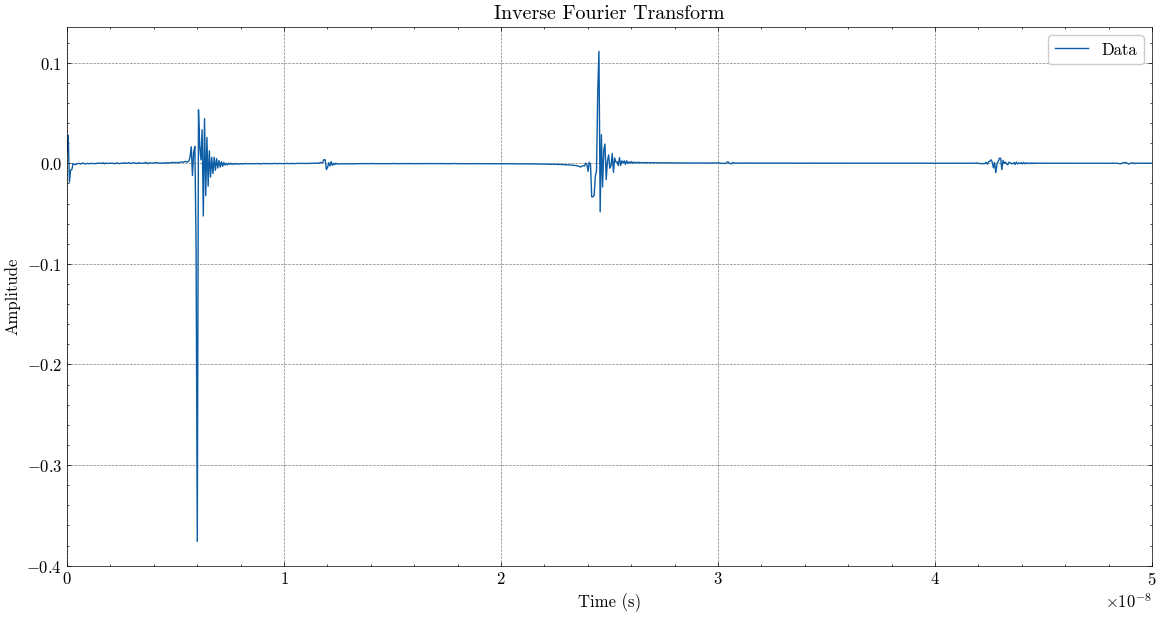

In [36]:
testing_time, testing_ifft = perform_ifft(lowpass50ohm_freq, lowpass50ohm_mag, lowpass50ohm_phase, ifft_return=True)

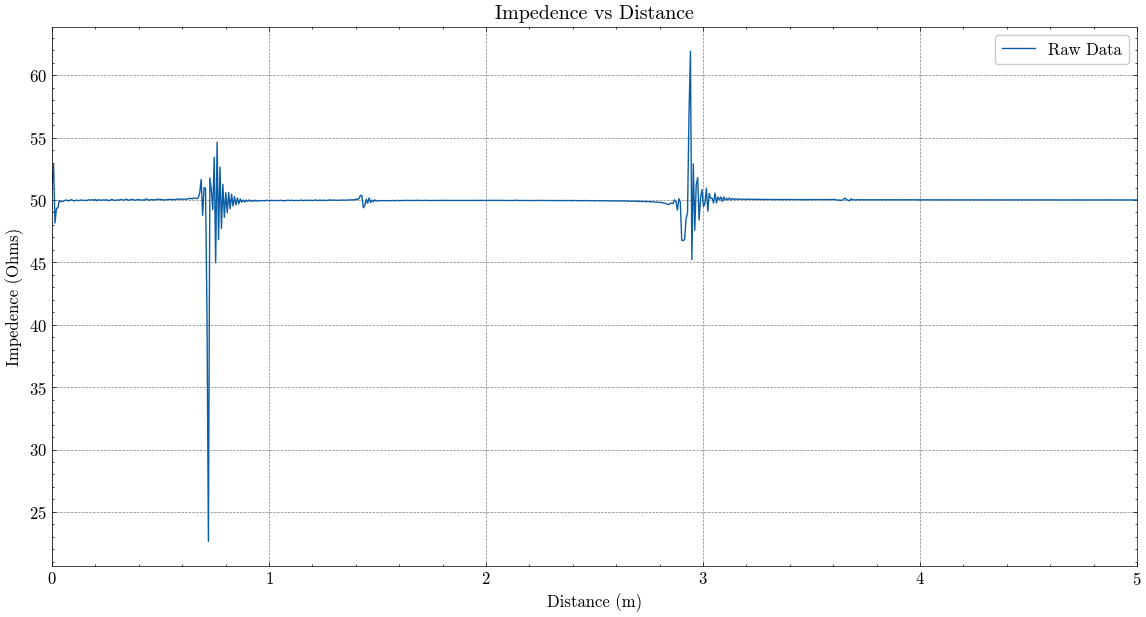

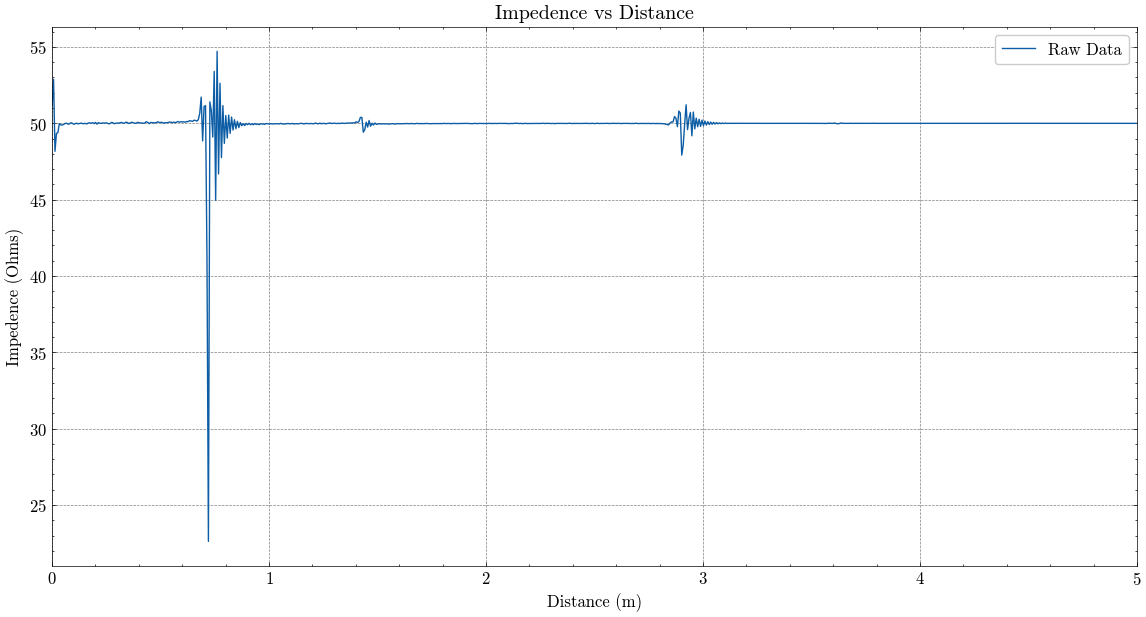

In [43]:
get_impedence_plot(lowpass50ohm_freq, lowpass50ohm_mag, lowpass50ohm_phase, limit=True, xlim_high=5)
get_impedence_plot(lowpass75ohm_freq, lowpass75ohm_mag, lowpass75ohm_phase, limit=True, xlim_high=5)

In [25]:
highpass50ohm_freq, highpass50ohm_mag = get_data("time_domain_data/HighPass_50Ohm_Terminator_MLOG_15102025.csv") 
highpass50ohm_phase = get_data("time_domain_data/HighPass_50Ohm_Terminator_PHAS_15102025.csv")[1]

highpass75ohm_freq, highpass75ohm_mag = get_data("time_domain_data/HighPass_75Ohm_Terminator_MLOG_15102025.csv")
highpass75ohm_phase = get_data("time_domain_data/HighPass_75Ohm_Terminator_PHAS_15102025.csv")[1]

C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\signal\_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)
C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


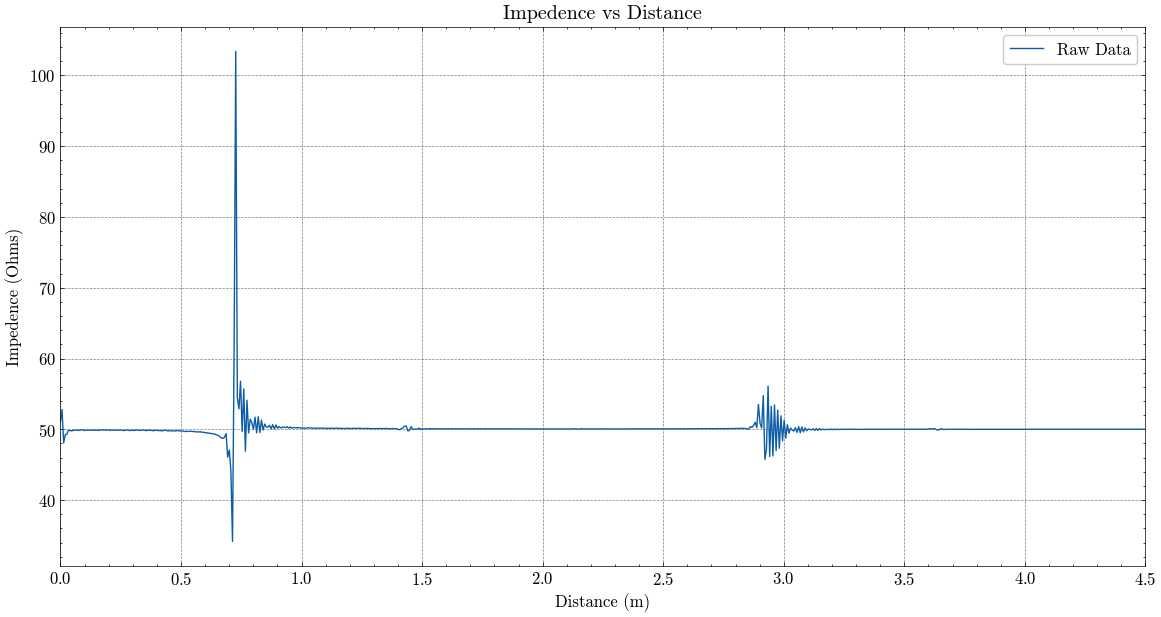

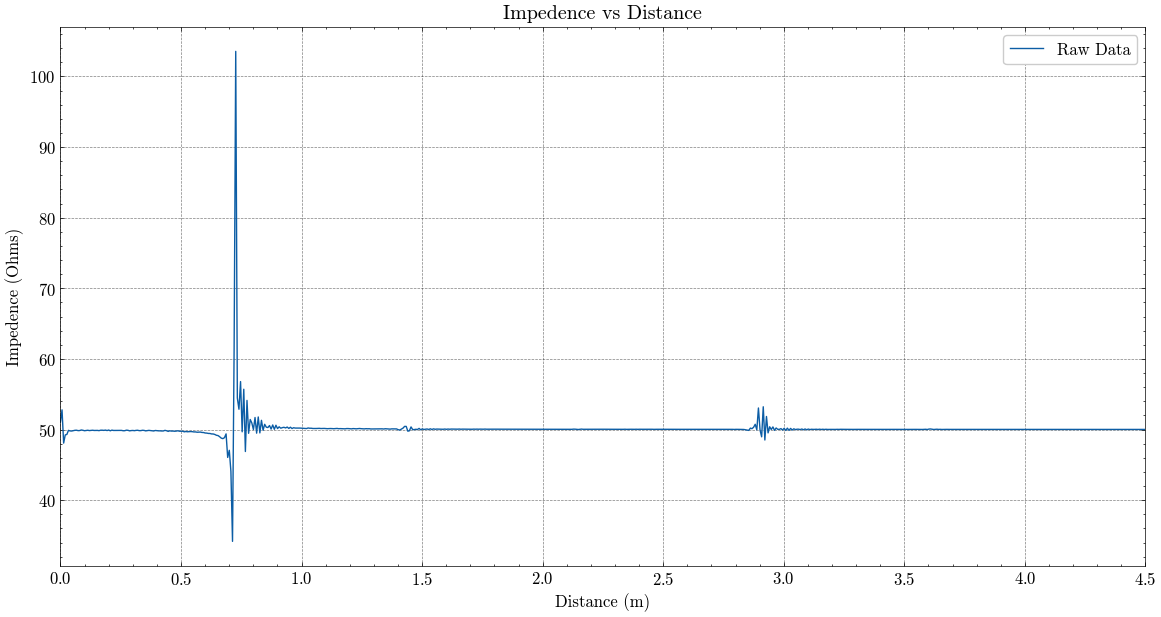

In [27]:
get_impedence_plot(highpass50ohm_freq, highpass50ohm_mag, highpass50ohm_phase, limit=True, xlim_high=4.5)
get_impedence_plot(highpass75ohm_freq, highpass75ohm_mag, highpass75ohm_phase, limit=True, xlim_high=4.5)

In [13]:
twpa_freqs, twpa_mag = get_data("full_july_data/02209_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.28V_11.952GHz_-8_dBm_pump.hdf5", csv=False, start_band=4e9, stop_band=8e9)
twpa_phase = get_data("full_july_data/02209_S21_4to5_10dBattprobe_pumpontopPHAS_7.533e-08_edelay_2.28V_11.952GHz_-8_dBm_pump.hdf5", csv=False, start_band=4e9, stop_band=8e9)[1]

In [14]:
twpa_freqs, twpa_mag = get_data("full_july_data/00081_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.28V_11.95GHz_5.0_dBm_pump.hdf5", 
                                csv=False, 
                                start_band=4e9, 
                                stop_band=8e9)
twpa_phase = get_data("full_july_data/00081_S21_4to5_10dBattprobe_pumpontopPHAS_7.533e-08_edelay_2.28V_11.95GHz_5.0_dBm_pump.hdf5", 
                      csv=False, 
                      start_band=4e9, 
                      stop_band=8e9)[1]

C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


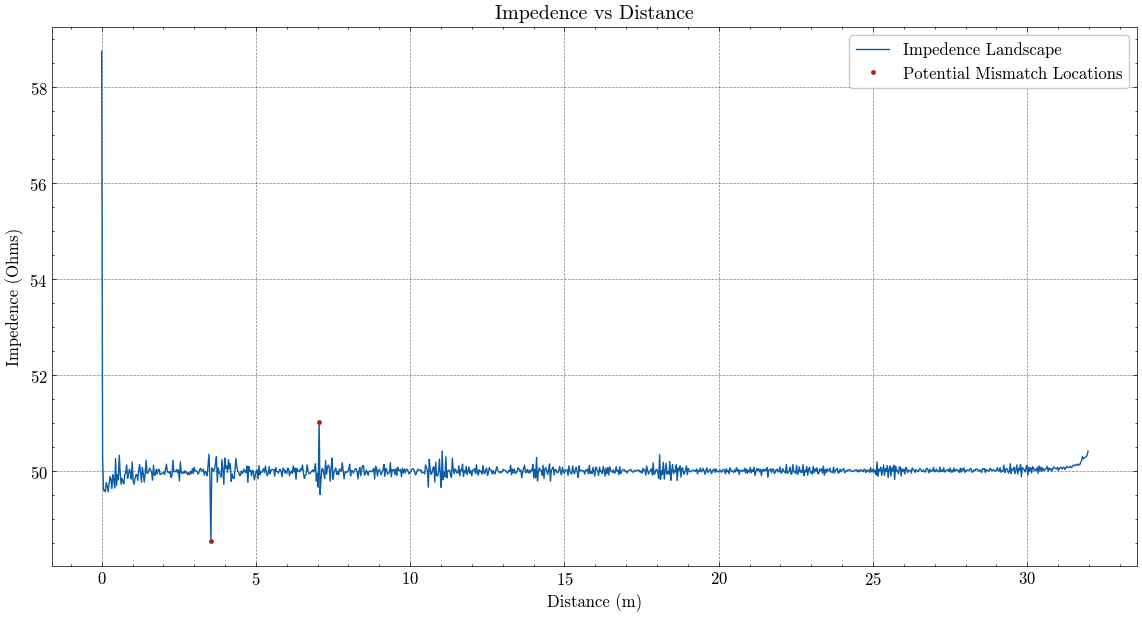

In [15]:
phase = np.pi/180 * twpa_phase ## Converting Phase from Degrees to Radians 
gamma_freq = 10**(twpa_mag/20) * np.exp(1j*phase) ## Reflection Coefficient in Frequency Domain

gamma_time = ifft(gamma_freq)   ## Perform the IFFT to get to time domain
N = len(twpa_freqs)
df = twpa_freqs[1] - twpa_freqs[0]
dt = 1 / (N*df)
time = np.arange(N) * dt

impedence = 50 * ((1 + gamma_time)/(1 - gamma_time))  ## Calculate the Impedence with the formula 
distance = 0.8*3e8*time/2  ## Calculate the distance travelled based on the velocity of light inside the cable + time data

peaks, _ = find_peaks(impedence, height=50.5)
troughs, _ = find_peaks(-impedence, height=-49.5)

distances = [distance[peaks], distance[troughs]]
impedences = [np.abs(impedence[peaks]), np.abs(impedence[troughs])]

plt.plot(distance, impedence, label='Impedence Landscape')
plt.plot(distance[peaks], impedence[peaks], 'o', markersize=2.5, color='firebrick', label='Potential Mismatch Locations')
plt.plot(distance[troughs], impedence[troughs], 'o', markersize=2.5, color='firebrick')
plt.xlabel('Distance (m)')
plt.ylabel('Impedence (Ohms)')
plt.title('Impedence vs Distance')
plt.legend()
# plt.xlim(0, 10)
# plt.ylim(0, 200)
plt.show()    

In [16]:
folder_path = ("full_july_data")
distances_total = []
impedences_total = []

folder_path = Path(folder_path)
files = sorted(folder_path.glob("*.hdf5")) 
for i, f in enumerate(files):
    file_on = h5py.File(f, 'r')
    pump_on = (file_on['Parameters']['EQUIPMENT_PARAMETERS']['pump_on'][()])
    measurement = ((file_on['Parameters']['VNA_PARAMETERS']['measurement_type'][()]).decode('utf-8'))        
    if ((pump_on == True) and (measurement == 'MLOG')):
        if (i + 2) <= len(files):
            j = files[i+1]
            freq, mag = get_data(f, csv=False, start_band=4e9, stop_band=8e9)
            phase = get_data(j, csv=False, start_band=4e9, stop_band=8e9)[1]
            
            phase = np.pi/180 * phase ## Converting Phase from Degrees to Radians 
            gamma_freq = 10**(mag/20) * np.exp(1j*phase) ## Reflection Coefficient in Frequency Domain

            gamma_time = ifft(gamma_freq)   ## Perform the IFFT to get to time domain
            N = len(freq)
            df = freq[1] - freq[0]
            dt = 1 / (N*df)
            time = np.arange(N) * dt

            impedence = 50 * ((1 + gamma_time)/(1 - gamma_time))  ## Calculate the Impedence with the formula 
            distance = 0.8*3e8*time/2  ## Calculate the distance travelled based on the velocity of light inside the cable + time data

            peaks, _ = find_peaks(impedence, height=50.5)
            troughs, _ = find_peaks(-impedence, height=-49.5)

            distances = [distance[peaks], distance[troughs]]
            impedences = [np.abs(impedence[peaks]), np.abs(impedence[troughs])]
            distances_total = distances_total + distances 
            impedences_total = impedences_total + impedences

In [17]:
mismatch_distances = []
mismatch_impedences = []
mismatch_impedences_absolute = []
for i in distances_total:
    for j in i:
        mismatch_distances.append(j)
for i in impedences_total:
    for j in i:
        mismatch_impedences.append(j)
        mismatch_impedences_absolute.append(np.abs(50-j))

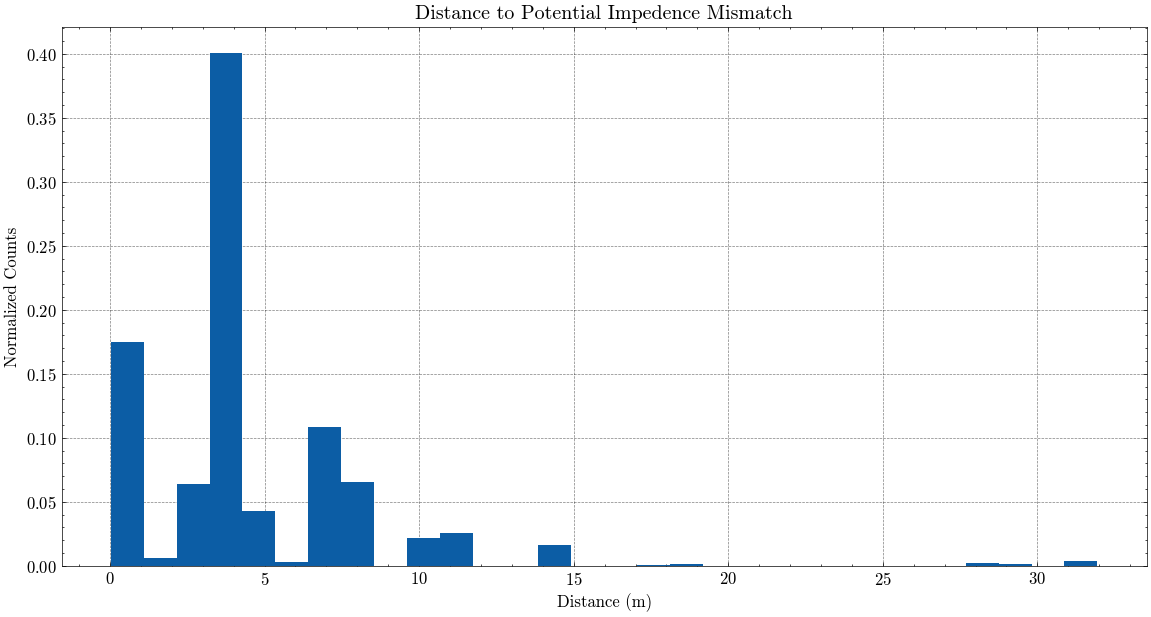

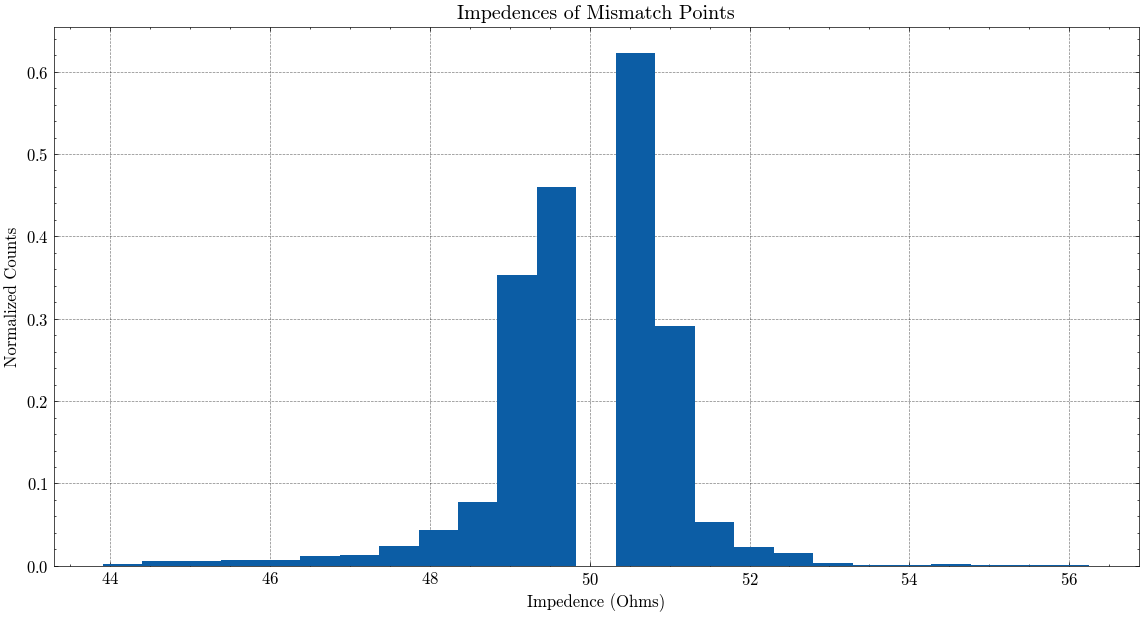

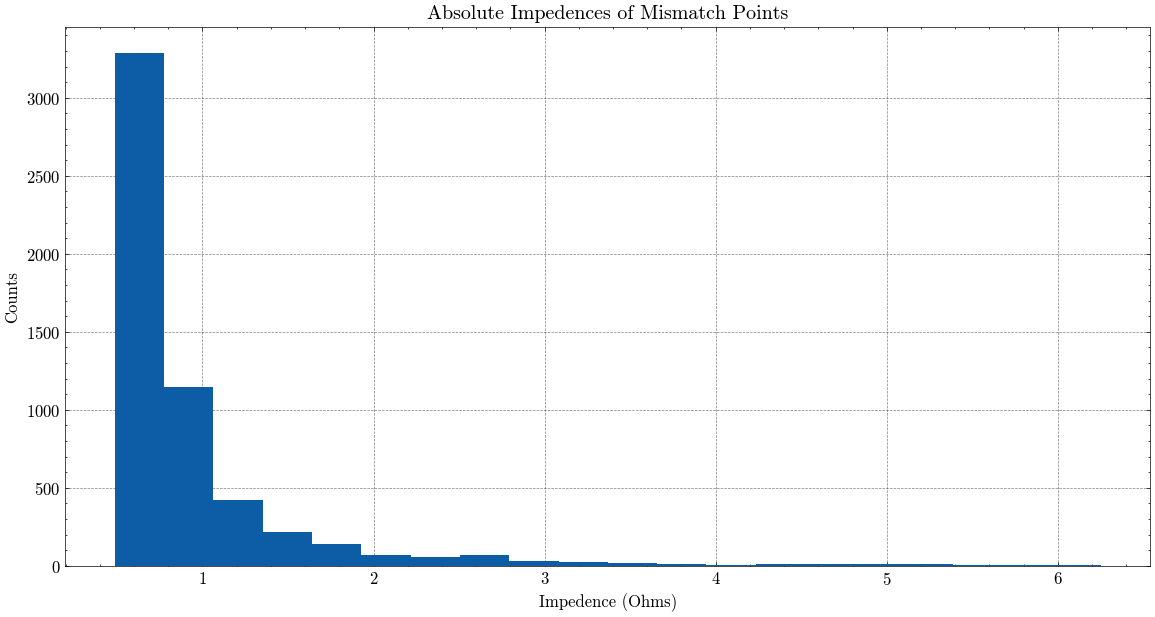

In [18]:
plt.hist(mismatch_distances, bins=30, density=True)
plt.title('Distance to Potential Impedence Mismatch')
plt.xlabel('Distance (m)')
plt.ylabel('Normalized Counts')
plt.show()

plt.hist(mismatch_impedences, bins=25, density=True)
plt.title('Impedences of Mismatch Points')
plt.xlabel('Impedence (Ohms)')
plt.ylabel('Normalized Counts')
plt.show()

plt.hist(mismatch_impedences_absolute, bins=20)
plt.title('Absolute Impedences of Mismatch Points')
plt.xlabel('Impedence (Ohms)')
plt.ylabel('Counts')
plt.show()